##Modelos de Regresion Lineal

In [2]:
import pandas as pd

In [3]:
url =  'https://raw.githubusercontent.com/Darwin2016/dataset2022/main/dataSETS/housingBOSTON-2.csv'
df = pd.read_csv(url, delimiter=',')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [4]:
df.shape

(506, 14)

In [5]:
#seleccionar grupo de columna del data frame
## x contiene los patrones sintomatologicos ##
X = df.drop(["MEDV"], axis=1)
y = df["MEDV"]

In [6]:
print("X : ",type(X))
print("y: ",type(y))

X :  <class 'pandas.core.frame.DataFrame'>
y:  <class 'pandas.core.series.Series'>


In [7]:
X.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [8]:
X.shape

(506, 13)

In [9]:
y.head()

,MEDV
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2


In [10]:
#Regresion Lineal Simple
#seleccionar grupo de columnas del data frame (AGE,RM,CRIM,DIS)

X = df[["RM"]]
y = df["MEDV"]

In [11]:
#Regresion Lineal Multiple
#seleccionar grupo de columnas del data frame (AGE,RM,CRIM,DIS)
## x contiene los patrones sintomatologicos ##
#X = df[["AGE","RM","CRIM","DIS"]]
#y = df["MEDV"]

In [12]:
X.head()

,RM
0,6.575
1,6.421
2,7.185
3,6.998
4,7.147


In [13]:
y.head()

,MEDV
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2


## usar sklearn para los modelos de prediccion

In [14]:
import numpy as np
from sklearn import linear_model # para aplicar el modelo de regresion lineal
from sklearn.model_selection import train_test_split #para separar del total de la data (training y testing)
from sklearn.metrics import mean_squared_error, r2_score ,mean_absolute_error

In [15]:
X.shape

(506, 1)

In [16]:
## División de los datos: 80% para entrenamiento y 20% para prueba ##
X_train, X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state=4)

In [17]:
X_train.shape

(404, 1)

In [18]:
X_test.shape

(102, 1)

In [19]:
X_train.shape

(404, 1)

In [20]:
X_test.head()

,RM
8,5.631
289,6.565
68,5.594
211,5.404
226,8.040


In [21]:
X_test.shape

(102, 1)

##Creación del Modelo de Aprendizaje (Regresión Lineal)

In [22]:
# Creamos el objeto de Regresión Linear
lm = linear_model.LinearRegression()

##Entrenamiento o Ajuste (aquí es donde aprende)

In [23]:
#Entrenar el modelo
lm.fit(X_train, y_train)

LinearRegression()

In [24]:
X_test.shape

(102, 1)

##Realizar predicciones usando los datos de Test

In [25]:
#Hacer una prediccion con datos separados para pruebas(test)
pred = lm.predict(X_test)

In [26]:
pred.shape

(102,)

##Mostrar las predicciones

In [27]:
print("VPred---VReal---Error")
for indice in range(10):
  error = np.abs(y_test.iloc[indice]-pred[indice]) #calculo del error (valor real - valor de prediccion)
  print("{:0.2f}   {:0.2f}  {:0.2f}".format(pred[indice],y_test.iloc[indice],error))

VPred---VReal---Error
16.57   16.50  0.07
24.91   24.80  0.11
16.24   17.40  1.16
14.54   19.30  4.76
38.09   37.60  0.49
23.59   24.20  0.61
31.02   35.40  4.38
21.36   19.90  1.46
27.48   27.50  0.02
21.02   17.00  4.02


##usando las metricas para ver el error cuadratico

In [28]:
# Error Cuadrado Medio
print("Error cuadratico medio: %.2f" % mean_squared_error(y_test,pred))

Error cuadratico medio: 51.61


In [29]:
# Puntaje de Varianza. El mejor puntaje es un 1.0
print('Variance score: %.2f' % r2_score(y_test, pred))

Variance score: 0.44


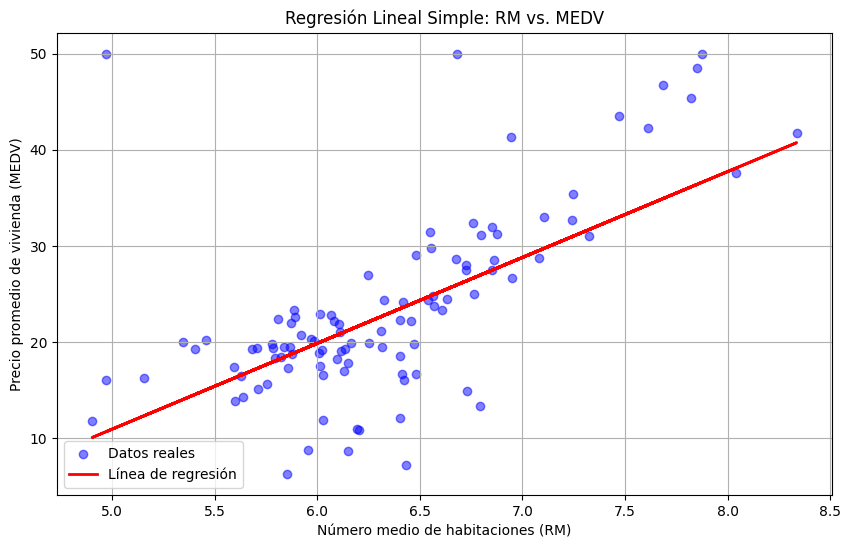

In [30]:
# Graficar modelo de RLS

import matplotlib.pyplot as plt
# Crear la gráfica
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Datos reales', alpha=0.5)  # Puntos reales
plt.plot(X_test, pred, color='red', linewidth=2, label='Línea de regresión')  # Línea de regresión
plt.xlabel('Número medio de habitaciones (RM)')
plt.ylabel('Precio promedio de vivienda (MEDV)')
plt.title('Regresión Lineal Simple: RM vs. MEDV')
plt.legend()
plt.grid(True)
plt.show()

In [31]:
print(lm.coef_)

[8.93363949]


In [32]:
print(lm.intercept_)

-33.73500109621233


y = 8.93 X - 33.73

##Con datos nuevos de entrada , datos que el modelo no conoce

In [33]:
# una entrada nueva
df5 = pd.DataFrame({"RM": [6.7]})

In [34]:
df5.head()

,RM
0,6.7


In [35]:
#print(float(df5.iloc[0]),float(df5["RM"]))
#rm = df5["RM"]
#print(type(rm))
#print(float(rm.iloc[0]))

prediccion = lm.predict(df5)
#print(prediccion)
print('Casa con {} habitaciones , su precio estimado: {:.2f}'.format(float(df5["RM"].iloc[0]),float(prediccion[0])))

Casa con 6.7 habitaciones , su precio estimado: 26.12


##Regresion Lineal Multiple

In [48]:
import pandas as pd
import numpy as np
from sklearn import linear_model # para aplicar el modelo de regresion lineal
from sklearn.model_selection import train_test_split #para separar del total de la data (training y testing)
from sklearn.metrics import mean_squared_error, r2_score ,mean_absolute_error
import matplotlib.pyplot as plt

In [37]:
url =  'https://raw.githubusercontent.com/Darwin2016/dataset2022/main/dataSETS/housingBOSTON-2.csv'
df = pd.read_csv(url, delimiter=',')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [38]:
#Regresion Lineal Multiple
#seleccionar grupo de columnas del data frame (AGE,RM,CRIM,DIS)

X = df[["AGE","RM","CRIM","DIS"]]
y = df["MEDV"]

In [39]:
## División de los datos: 80% para entrenamiento y 20% para prueba ##
X_train, X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state=4)

In [40]:
# Creamos el objeto de Regresión Linear
lm = linear_model.LinearRegression()
#Entrenar el modelo
lm.fit(X_train, y_train)
#Hacer una prediccion con datos separados para pruebas(test)
pred = lm.predict(X_test)

In [41]:
print("VPred---VReal---Error")
for indice in range(10):
  error = np.abs(y_test.iloc[indice]-pred[indice]) #calculo del error (valor real - valor de prediccion)
  print("{:0.2f}   {:0.2f}  {:0.2f}".format(pred[indice],y_test.iloc[indice],error))

VPred---VReal---Error
13.51   16.50  2.99
27.04   24.80  2.24
18.72   17.40  1.32
14.55   19.30  4.75
35.81   37.60  1.79
28.88   24.20  4.68
31.48   35.40  3.92
20.50   19.90  0.60
23.20   27.50  4.30
20.77   17.00  3.77


In [42]:
# Error Cuadrado Medio
print("Error cuadratico medio: %.2f" % mean_squared_error(y_test,pred))

Error cuadratico medio: 43.40


In [43]:
# Puntaje de Varianza. El mejor puntaje es un 1.0
print('Variance score: %.2f' % r2_score(y_test, pred))

Variance score: 0.53


In [44]:
print('Mean Absolute Error(MAE):{:.2f}'.format(mean_absolute_error(y_test, pred)))
print('Mean Squared Error(MSE):{:.2f}'.format(mean_squared_error(y_test, pred)))
print('Root Mean Squared Error(RMSE):{:.2f}'.format(np.sqrt(mean_squared_error(y_test, pred))))

Mean Absolute Error(MAE):3.87
Mean Squared Error(MSE):43.40
Root Mean Squared Error(RMSE):6.59


In [45]:
# una entrada nueva
df5 = pd.DataFrame({"AGE":[60.3],"RM": [6.7],"CRIM":[0.023],"DIS":[3.7]})

In [46]:
prediccion = lm.predict(df5)
print(prediccion)
print('Casa una edad de {} años y con {} habitaciones , su precio estimado: {:.2f}'.format(float(df5["AGE"].iloc[0]),float(df5["RM"].iloc[0]),float(prediccion[0])))

[27.39426875]
Casa una edad de 60.3 años y con 6.7 habitaciones , su precio estimado: 27.39


##PREDICTORES DE MAYOR IMPORTANCIA PARA DETERMINAR NUEVAMENTE EL ERROR Y % DE PRECISION

In [51]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
print("✅ Imports completos")

✅ Imports completos


In [52]:
# Modelo completo para obtener coeficientes/importancia
print("=== MODELO COMPLETO (13 features) ===")
X_full = df.drop('MEDV', axis=1)
y = df['MEDV']
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y, test_size=0.2, random_state=4)
lm_full = LinearRegression()
lm_full.fit(X_train_full, y_train_full)
pred_full = lm_full.predict(X_test_full)

mse_full = mean_squared_error(y_test_full, pred_full)
r2_full = r2_score(y_test_full, pred_full)
mae_full = mean_absolute_error(y_test_full, pred_full)
rmse_full = np.sqrt(mse_full)

print(f'MSE Completo: {mse_full:.2f}')
print(f'R² Completo: {r2_full:.2f} ({r2_full*100:.1f}%)')
print(f'MAE Completo: {mae_full:.2f}')
print(f'RMSE Completo: {rmse_full:.2f}')

=== MODELO COMPLETO (13 features) ===
MSE Completo: 25.42
R² Completo: 0.73 (72.6%)
MAE Completo: 3.37
RMSE Completo: 5.04


In [53]:
# Importancia por magnitud absoluta de coeficientes
importancia = pd.DataFrame({
    'feature': X_full.columns,
    'coef': lm_full.coef_
})
importancia['abs_coef'] = np.abs(importancia['coef'])
importancia = importancia.sort_values('abs_coef', ascending=False)
print("\nTop 10 predictores:")
print(importancia.head(10))


Top 10 predictores:
    feature       coef   abs_coef
4       NOX -16.686589  16.686589
5        RM   3.884107   3.884107
3      CHAS   3.234045   3.234045
7       DIS  -1.541295   1.541295
10  PTRATIO  -0.906296   0.906296
12    LSTAT  -0.457724   0.457724
8       RAD   0.293208   0.293208
0      CRIM  -0.115966   0.115966
1        ZN   0.047125   0.047125
9       TAX  -0.013406   0.013406


In [54]:
# Seleccionar TOP 5 predictores
top5_features = importancia.head(5)['feature'].tolist()
print(f"\nTop 5 features: {top5_features}")

X_top5 = df[top5_features]
X_train_top5, X_test_top5, y_train_top5, y_test_top5 = train_test_split(X_top5, y, test_size=0.2, random_state=4)

# Entrenar modelo TOP 5
lm_top5 = LinearRegression()
lm_top5.fit(X_train_top5, y_train_top5)
pred_top5 = lm_top5.predict(X_test_top5)

mse_top5 = mean_squared_error(y_test_top5, pred_top5)
r2_top5 = r2_score(y_test_top5, pred_top5)
mae_top5 = mean_absolute_error(y_test_top5, pred_top5)
rmse_top5 = np.sqrt(mse_top5)

print("\n=== RESULTADOS TOP 5 ===")
print(f'MSE Top 5: {mse_top5:.2f}')
print(f'R² Top 5: {r2_top5:.2f} ({r2_top5*100:.1f}%)')
print(f'MAE Top 5: {mae_top5:.2f}')
print(f'RMSE Top 5: {rmse_top5:.2f}')


Top 5 features: ['NOX', 'RM', 'CHAS', 'DIS', 'PTRATIO']

=== RESULTADOS TOP 5 ===
MSE Top 5: 38.33
R² Top 5: 0.59 (58.7%)
MAE Top 5: 3.89
RMSE Top 5: 6.19


In [55]:
# Tabla de comparación
comparacion = pd.DataFrame({
    'Modelo': ['RLS (RM)', 'RLM (4 vars)', 'Completo (13)', 'Top 5'],
    'MSE': [51.61, 43.40, mse_full, mse_top5],
    'R²': [0.44, 0.53, r2_full, r2_top5],
    'MAE': [3.87, 3.87, mae_full, mae_top5],
    'RMSE': [6.59, 6.59, rmse_full, rmse_top5]
})
print("\n=== COMPARACIÓN FINAL ===")
print(comparacion.round(2))



=== COMPARACIÓN FINAL ===
          Modelo    MSE    R²   MAE  RMSE
0       RLS (RM)  51.61  0.44  3.87  6.59
1   RLM (4 vars)  43.40  0.53  3.87  6.59
2  Completo (13)  25.42  0.73  3.37  5.04
3          Top 5  38.33  0.59  3.89  6.19


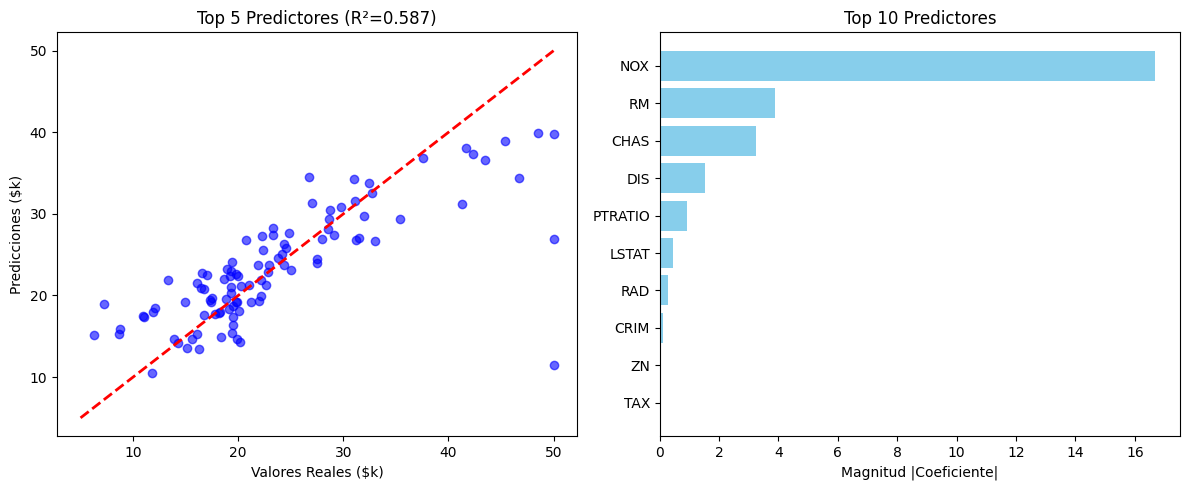

In [56]:
# Gráficas
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Predicciones vs reales
plt.subplot(1, 2, 1)
plt.scatter(y_test_top5, pred_top5, alpha=0.6, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Valores Reales ($k)')
plt.ylabel('Predicciones ($k)')
plt.title(f'Top 5 Predictores (R²={r2_top5:.3f})')

# Importancia TOP 10
plt.subplot(1, 2, 2)
top10_plot = importancia.head(10)
plt.barh(range(len(top10_plot)), top10_plot['abs_coef'], color='skyblue')
plt.yticks(range(len(top10_plot)), top10_plot['feature'])
plt.xlabel('Magnitud |Coeficiente|')
plt.title('Top 10 Predictores')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


In [57]:
# Predicción con datos nuevos (usando TOP 5)
print(f"Variables TOP 5: {top5_features}")
ejemplo_data = {
    top5_features[0]: [6.15],  # LSTAT típico
    top5_features[1]: [6.5],   # RM típico
    top5_features[2]: [19.5],  # PTRATIO típico
    top5_features[3]: [3.0],   # DIS típico
    top5_features[4]: [300.0]  # TAX típico
}
ejemplo_df = pd.DataFrame(ejemplo_data)
pred_ejemplo = lm_top5.predict(ejemplo_df)
print(f"\nPredicción ejemplo: ${pred_ejemplo[0]:.2f} mil USD")
print("Datos de entrada:")
print(ejemplo_df.T)


Variables TOP 5: ['NOX', 'RM', 'CHAS', 'DIS', 'PTRATIO']

Predicción ejemplo: $-400.85 mil USD
Datos de entrada:
              0
NOX        6.15
RM         6.50
CHAS      19.50
DIS        3.00
PTRATIO  300.00


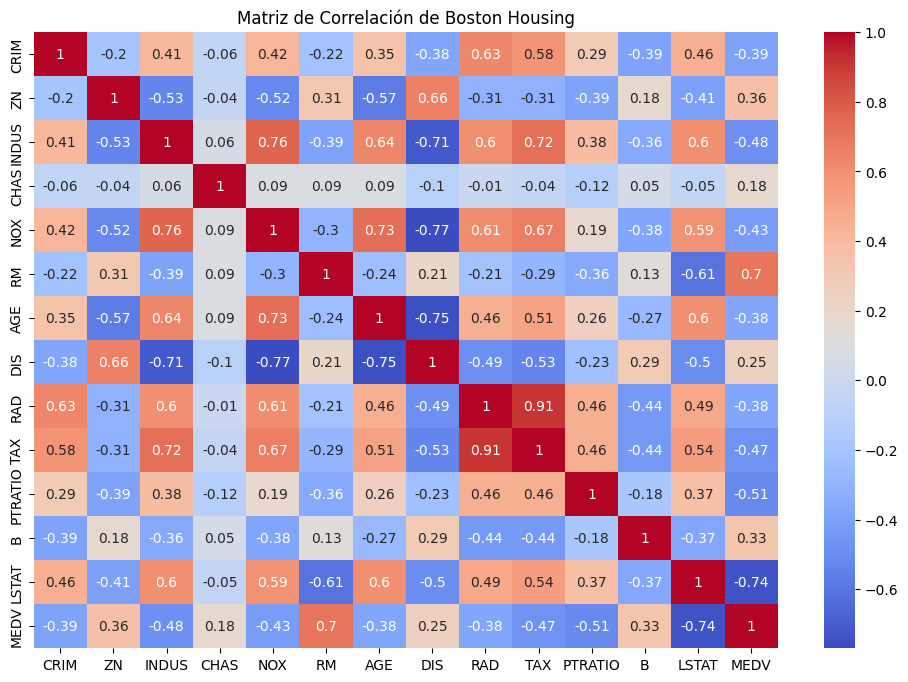

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculamos la matriz de correlación
correlation_matrix = df.corr().round(2)

# Graficamos el mapa de calor para identificar los mejores predictores
plt.figure(figsize=(12, 8))
sns.heatmap(data=correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Matriz de Correlación de Boston Housing")
plt.show()

# Seleccionamos las variables con mayor correlación absoluta con MEDV
# Generalmente LSTAT (-0.74) y RM (0.7) son las más altas.

In [59]:
# Basado en la correlación, seleccionamos los mejores predictores
import numpy as np
from sklearn.model_selection import train_test_split

# Seleccionamos LSTAT y RM como predictores principales
X_importantes = df[['LSTAT', 'RM']]
y = df['MEDV']

# Dividimos en entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_importantes, y, test_size=0.2, random_state=42)

print("Nuevos predictores seleccionados: LSTAT, RM")

Nuevos predictores seleccionados: LSTAT, RM


In [60]:
from sklearn.linear_model import LinearRegression

# Creamos y entrenamos el modelo con las variables importantes
lm_importante = LinearRegression()
lm_importante.fit(X_train, y_train)

# Realizamos las predicciones
y_pred = lm_importante.predict(X_test)

In [61]:
from sklearn import metrics

# Métricas de error
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

print('--- Métricas del Modelo Optimizado ---')
print('Mean Absolute Error (MAE): {:.2f}'.format(mae))
print('Mean Squared Error (MSE): {:.2f}'.format(mse))
print('Root Mean Squared Error (RMSE): {:.2f}'.format(rmse))
print('Porcentaje de Precisión (R^2): {:.2f}%'.format(r2 * 100))

--- Métricas del Modelo Optimizado ---
Mean Absolute Error (MAE): 3.90
Mean Squared Error (MSE): 31.24
Root Mean Squared Error (RMSE): 5.59
Porcentaje de Precisión (R^2): 57.40%
